Let's start out notebook with some imports

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from math import gcd
from functools import reduce
from scipy.stats import norm
from scipy.stats import pearsonr, spearmanr
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import gaussian_kde

import seaborn as sns
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))
from pathlib import Path

from typing import Optional,Tuple

sns.set_theme(style="whitegrid", context="notebook")

# 0. DATA

The dataset is structured as two matrices of shape (N_DAYS, N_STOCKS):

- **trades**: trades[day][stock] is the DataFrame of trades for a given stock on a given day.
- **updates**: updates[day][stock] is the DataFrame of order book updates for a given stock on a given day.

In [2]:
N_STOCKS = 3
N_DAYS = 5

# Let's work on day = day for the stock = stock
day = 0
stock = 0

In [3]:
def load_trades(n_days: int, n_stocks: int, usecols=None, **read_csv_kwargs):
    trades = [[None for _ in range(n_stocks)] for _ in range(n_days)]

    for day in range(n_days):
        for stock in range(n_stocks):
            path = f"stock{stock}_day{day}_trades.csv.gz"
            trades[day][stock] = pd.read_csv(
                path,
                compression="gzip",
                usecols=usecols,
                **read_csv_kwargs
            )
    return trades

def load_updates(n_days: int, n_stocks: int, usecols=None, **read_csv_kwargs):
    updates = [[None for _ in range(n_stocks)] for _ in range(n_days)]

    for day in range(n_days):
        for stock in range(n_stocks):
            path = f"stock{stock}_day{day}_updates.csv.gz"
            updates[day][stock] = pd.read_csv(
                path,
                compression="gzip",
                usecols=usecols,
                **read_csv_kwargs
            )
    return updates

trades = load_trades(N_DAYS,N_STOCKS)
updates = load_updates(N_DAYS,N_STOCKS)

In [4]:
trade = trades[day][stock]
update = updates[day][stock]

# Question 1

## 1.1.1 : Trade Data Preparation


In [5]:
def _print_header(title: str) -> None:
    bar = "─" * len(title)
    print(f"\n{title}\n{bar}")


def _print_trades_summary(df: pd.DataFrame, qc: dict) -> None:
    _print_header("Trades Data Summary")

    print("Shape")
    print("-----")
    print(f"Raw rows        : {qc['n_rows_raw']}")
    print(f"Rows after prep : {qc['n_rows_after']}")

    print("\nMissing & invalid values")
    print("------------------------")
    print(f"Missing ts      : {qc['n_ts_na']}")
    print(f"Missing price   : {qc['n_price_na']}")
    print(f"Missing qty     : {qc['n_qty_na']}")
    print(f"price <= 0      : {qc['n_price_leq_0_raw']}")
    print(f"qty <= 0        : {qc['n_qty_leq_0_raw']}")
    print(f"Bad rows total  : {qc['n_bad_rows']}")

    print("\nTimestamp quality")
    print("-----------------")
    print(f"Decreasing ts (raw)   : {qc['n_ts_decreasing_raw']}")
    print(f"Decreasing ts (after) : {qc['n_ts_decreasing_after']}")
    print(f"Equal ts (after)      : {qc['n_ts_equal_after']}")

    if len(df) > 0:
        print("\nPrepared data overview")
        print("----------------------")
        print(f"First timestamp : {df['ts'].min()}")
        print(f"Last timestamp  : {df['ts'].max()}")
        print(f"Price range     : [{df['price'].min():.6g}, {df['price'].max():.6g}]")
        print(f"Qty range       : [{df['qty'].min():.6g}, {df['qty'].max():.6g}]")

    print()

In [6]:
def prepare_trades_df(
    df_raw: pd.DataFrame,
    *,
    drop_bad_rows: bool = False,
    print_summary: bool = True
):
    """
    Step 1: standardize a single stock-day trades dataframe.

    Input:
      df_raw with columns ['price', 'qty', 'ts']

    Output:
      df: cleaned & sorted dataframe, with derived columns ['price', 'qty', 'ts','dt','dprice','logp','dlogp']
      qc: dict of quality-control metrics
    """
    qc = {}

    df = df_raw.loc[:, ["price", "qty", "ts"]].copy()

    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["qty"] = pd.to_numeric(df["qty"], errors="coerce")

    qc["n_rows_raw"] = len(df)
    qc["n_ts_na"] = int(df["ts"].isna().sum())
    qc["n_price_na"] = int(df["price"].isna().sum())
    qc["n_qty_na"] = int(df["qty"].isna().sum())

    ts_raw = df["ts"]
    qc["n_ts_decreasing_raw"] = int((ts_raw.diff() < pd.Timedelta(0)).sum())

    qc["n_price_leq_0_raw"] = int((df["price"] <= 0).sum(skipna=True))
    qc["n_qty_leq_0_raw"] = int((df["qty"] <= 0).sum(skipna=True))

    bad_mask = (
        df["ts"].isna()
        | df["price"].isna()
        | df["qty"].isna()
        | (df["price"] <= 0)
        | (df["qty"] <= 0)
    )
    qc["n_bad_rows"] = int(bad_mask.sum())

    if drop_bad_rows:
        df = df.loc[~bad_mask].copy()

    df.sort_values(["ts"], kind="mergesort", inplace=True)
    df.reset_index(drop=True, inplace=True)

    qc["n_rows_after"] = len(df)
    qc["n_ts_decreasing_after"] = int((df["ts"].diff() < pd.Timedelta(0)).sum())
    qc["n_ts_equal_after"] = int((df["ts"].diff() == pd.Timedelta(0)).sum())

    df["dt"] = df["ts"].diff()
    df["dprice"] = df["price"].diff()
    df["logp"] = np.log(df["price"].astype(float))
    df["dlogp"] = df["logp"].diff()

    if print_summary:
        _print_trades_summary(df, qc)

    return df, qc

trade, quality_control = prepare_trades_df(trade,print_summary = True)


Trades Data Summary
───────────────────
Shape
-----
Raw rows        : 19076
Rows after prep : 19076

Missing & invalid values
------------------------
Missing ts      : 0
Missing price   : 0
Missing qty     : 0
price <= 0      : 0
qty <= 0        : 0
Bad rows total  : 0

Timestamp quality
-----------------
Decreasing ts (raw)   : 0
Decreasing ts (after) : 0
Equal ts (after)      : 9507

Prepared data overview
----------------------
First timestamp : 2026-01-26 09:00:27.018202
Last timestamp  : 2026-01-26 17:29:58.691949
Price range     : [54.84, 55.74]
Qty range       : [1, 11400]



It seems that our data doesn't suffer from any missing values and is, indeed, sorted with respect to time stamps. 

## 1.1.2 General statistics

We are going to compute some basic statistics : 

**Time**
- start / end timestamp
- total span (seconds)
- inter-trade duration quantiles
- count of duplicate timestamps

**Prices**
- min / median / max
- fraction of zero price changes

**Returns**
- mean and standard deviation (event time)
- 95% and 99% absolute return quantiles

**Quantities**
- sum, mean, median
- upper quantiles and max

**Notional**
- total traded notional (price × quantity)

In [7]:
def _fmt_stat_value(x):
    if pd.isna(x):
        return "NA"
    if isinstance(x, pd.Timestamp):
        return x.strftime("%Y-%m-%d %H:%M:%S")
    if isinstance(x, (int, np.integer)):
        return f"{int(x)}"
    if isinstance(x, (float, np.floating)):
        return f"{x:.6g}"
    return str(x)


def print_basic_stats_summary(stats: dict) -> None:
    _print_header("Basic Trade Statistics")

    table = pd.Series(stats, name="value").to_frame()
    table["value"] = table["value"].map(_fmt_stat_value)

    print(table.to_string())
    print()

In [8]:
def compute_basic_stats(df: pd.DataFrame, *, print_summary: bool = True) -> dict:
    """
    Compute general descriptive statistics for ONE stock-day.

    Input
    -----
    df : pd.DataFrame
        Trades dataframe sorted by timestamp.
        Expected columns:
            - 'ts'     : trade timestamp (datetime-like)
            - 'price'  : trade price (strictly positive numeric)
            - 'qty'    : trade quantity (strictly positive numeric)

        Optional precomputed columns:
            - 'dt'     : inter-trade time difference, typically df['ts'].diff()
            - 'dprice' : price increment, typically df['price'].diff()
            - 'dlogp'  : log-price increment, typically np.log(df['price']).diff()

    Returns
    -------
    dict
        Dictionary of descriptive statistics for this stock-day.
    """
    out = {}
    out["n_trades"] = int(len(df))

    if len(df) == 0:
        for k in [
            "ts_min", "ts_max", "span_seconds",
            "n_duplicate_ts", "dt_median_ms", "dt_p90_ms", "dt_p99_ms", "dt_max_ms",
            "price_min", "price_median", "price_max", "frac_zero_dprice",
            "ret_mean", "ret_std", "ret_p95_abs", "ret_p99_abs",
            "qty_sum", "qty_mean", "qty_median", "qty_p95", "qty_p99", "qty_max",
            "notional_sum"
        ]:
            out[k] = np.nan

        if print_summary:
            print_basic_stats_summary(out)
        return out

    # --- Time span ---
    ts_min = df["ts"].iloc[0]
    ts_max = df["ts"].iloc[-1]
    out["ts_min"] = ts_min
    out["ts_max"] = ts_max
    out["span_seconds"] = float((ts_max - ts_min) / pd.Timedelta(seconds=1))

    # --- Inter-trade durations ---
    dt = df["dt"] if "dt" in df.columns else df["ts"].diff()
    dt_ms = (dt / pd.Timedelta(milliseconds=1)).to_numpy()
    dt_ms = dt_ms[~np.isnan(dt_ms)]

    out["n_duplicate_ts"] = int(np.sum(dt_ms == 0)) if dt_ms.size else 0

    if dt_ms.size:
        out["dt_median_ms"] = float(np.quantile(dt_ms, 0.50))
        out["dt_p90_ms"] = float(np.quantile(dt_ms, 0.90))
        out["dt_p99_ms"] = float(np.quantile(dt_ms, 0.99))
        out["dt_max_ms"] = float(np.max(dt_ms))
    else:
        out["dt_median_ms"] = np.nan
        out["dt_p90_ms"] = np.nan
        out["dt_p99_ms"] = np.nan
        out["dt_max_ms"] = np.nan

    # --- Price stats ---
    price = df["price"].to_numpy(dtype=float)
    out["price_min"] = float(np.nanmin(price))
    out["price_median"] = float(np.nanmedian(price))
    out["price_max"] = float(np.nanmax(price))

    dprice = df["dprice"] if "dprice" in df.columns else df["price"].diff()
    dprice = dprice.to_numpy(dtype=float)
    dprice = dprice[~np.isnan(dprice)]
    out["frac_zero_dprice"] = float(np.mean(dprice == 0)) if dprice.size else np.nan

    # --- Event-time log return stats ---
    dlogp = df["dlogp"] if "dlogp" in df.columns else np.log(df["price"]).diff()
    r = dlogp.to_numpy(dtype=float)
    r = r[~np.isnan(r)]

    if r.size:
        out["ret_mean"] = float(np.mean(r))
        out["ret_std"] = float(np.std(r, ddof=1)) if r.size > 1 else 0.0
        abs_r = np.abs(r)
        out["ret_p95_abs"] = float(np.quantile(abs_r, 0.95))
        out["ret_p99_abs"] = float(np.quantile(abs_r, 0.99))
    else:
        out["ret_mean"] = np.nan
        out["ret_std"] = np.nan
        out["ret_p95_abs"] = np.nan
        out["ret_p99_abs"] = np.nan

    # --- Quantity stats ---
    qty = df["qty"].to_numpy(dtype=float)
    out["qty_sum"] = float(np.nansum(qty))
    out["qty_mean"] = float(np.nanmean(qty))
    out["qty_median"] = float(np.nanmedian(qty))
    out["qty_p95"] = float(np.nanquantile(qty, 0.95))
    out["qty_p99"] = float(np.nanquantile(qty, 0.99))
    out["qty_max"] = float(np.nanmax(qty))

    # --- Notional ---
    out["notional_sum"] = float(np.nansum(df["price"].to_numpy(dtype=float) * qty))

    if print_summary:
        print_basic_stats_summary(out)

    return out

stats_trade = compute_basic_stats(trade)


Basic Trade Statistics
──────────────────────
                                value
n_trades                        19076
ts_min            2026-01-26 09:00:27
ts_max            2026-01-26 17:29:58
span_seconds                  30571.7
n_duplicate_ts                   9507
dt_median_ms                    0.008
dt_p90_ms                      4428.1
dt_p99_ms                     25061.2
dt_max_ms                     91165.2
price_min                       54.84
price_median                    55.42
price_max                       55.74
frac_zero_dprice             0.851429
ret_mean                   6.0651e-07
ret_std                   8.04423e-05
ret_p95_abs                0.00018075
ret_p99_abs               0.000360295
qty_sum                   2.57452e+06
qty_mean                      134.961
qty_median                        114
qty_p95                           333
qty_p99                           758
qty_max                         11400
notional_sum              1.42725e+08



## 1.1.3 Displaying some results

We first, begin by plotting the distribution of the inter arrival time of our orders.

In [9]:
def _get_ax(ax: Optional[plt.Axes], figsize: Tuple[int, int] = (10, 4)) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    return ax


def _safe_log_bins(values: np.ndarray, bins: int) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    vmin = float(np.min(values))
    vmax = float(np.max(values))

    if vmin <= 0:
        raise ValueError("Log-scale bins require strictly positive values.")

    if np.isclose(vmin, vmax):
        vmin = max(vmin * 0.9, np.finfo(float).eps)
        vmax = vmax * 1.1

    return np.logspace(np.log10(vmin), np.log10(vmax), bins)

<Axes: title={'center': 'Inter-trade Duration Distribution'}, xlabel='dt (ms)', ylabel='Count'>

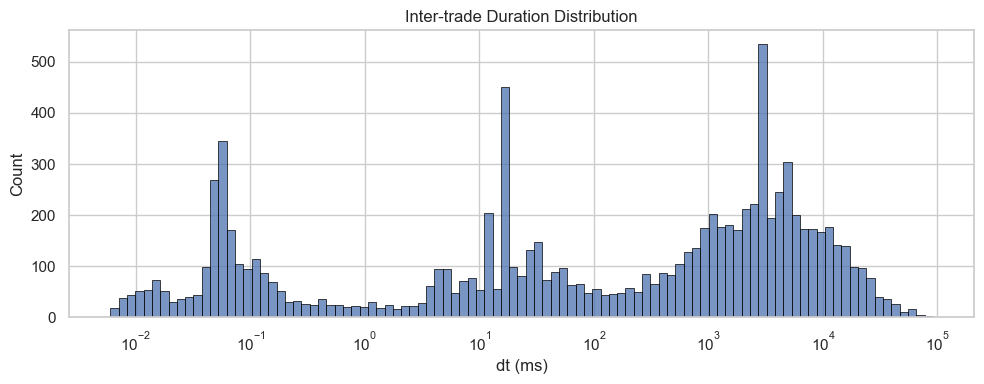

In [10]:
def plot_dt_hist(
    df: pd.DataFrame,
    *,
    title: Optional[str] = None,
    bins: int = 100,
    log_x: bool = True,
    ax: Optional[plt.Axes] = None,
) -> Optional[plt.Axes]:
    """
    Plot histogram of inter-trade time intervals.

    Input
    -----
    df : pd.DataFrame
        Trades dataframe containing:
        - 'ts' : timestamps
        - optional 'dt' : precomputed df['ts'].diff()

    Output
    ------
    Displays a histogram of positive dt values (in milliseconds).
    Returns the matplotlib axes used for the plot.
    """
    
    dt = df["dt"] if "dt" in df.columns else df["ts"].diff()

    if pd.api.types.is_timedelta64_dtype(dt):
        dt_ms = (dt.dt.total_seconds() * 1000.0).to_numpy(dtype=float)
    else:
        dt_ms = pd.to_numeric(dt, errors="coerce").to_numpy(dtype=float)

    dt_ms = dt_ms[np.isfinite(dt_ms)]
    dt_ms = dt_ms[dt_ms > 0]
    if dt_ms.size == 0:
        return None

    ax = _get_ax(ax)
    hist_bins = _safe_log_bins(dt_ms, bins) if log_x else bins
    sns.histplot(x=dt_ms, bins=hist_bins, ax=ax, color="#4C72B0",edgecolor ="black",linewidth=0.5)
    

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("dt (ms)")
    ax.set_ylabel("Count")
    ax.set_title(title or "Inter-trade Duration Distribution")
    ax.figure.tight_layout()
    return ax

plot_dt_hist(trade,log_x=True, bins=100)

We are going to display the evolution of the price 

<Axes: title={'center': 'Price in Event Time'}, xlabel='Trade index (event time)', ylabel='Price'>

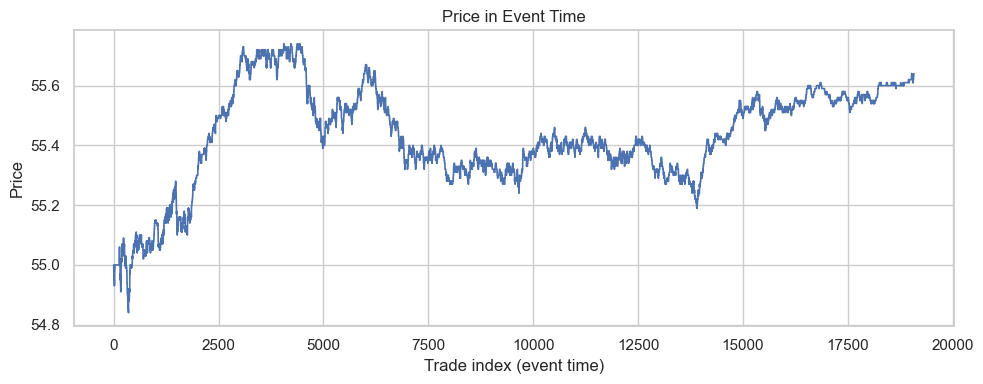

In [11]:
def plot_price_event_time(
    df: pd.DataFrame,
    *,
    title: Optional[str] = None,
    max_points: int = 200_000,
    ax: Optional[plt.Axes] = None,
) -> Optional[plt.Axes]:
    """
    Plot trade price in event time (trade index).

    Input
    -----
    df : pd.DataFrame
        Trades dataframe containing a 'price' column.

    Output
    ------
    Displays price as a function of trade index.
    Returns the matplotlib axes used for the plot.
    """

    n = len(df)
    if n == 0:
        return None

    if n > max_points:
        idx = np.linspace(0, n - 1, max_points).astype(int)
        plot_df = pd.DataFrame(
            {"trade_index": idx, "price": df["price"].to_numpy(dtype=float)[idx]}
        )
    else:
        plot_df = pd.DataFrame(
            {
                "trade_index": np.arange(n),
                "price": df["price"].to_numpy(dtype=float),
            }
        )

    ax = _get_ax(ax)
    sns.lineplot(data=plot_df, x="trade_index", y="price", ax=ax, linewidth=1.2)
    ax.set_xlabel("Trade index (event time)")
    ax.set_ylabel("Price")
    ax.set_title(title or "Price in Event Time")
    ax.figure.tight_layout()
    return ax

plot_price_event_time(trade)

We are going to display the traded quantity distribution accros the day.

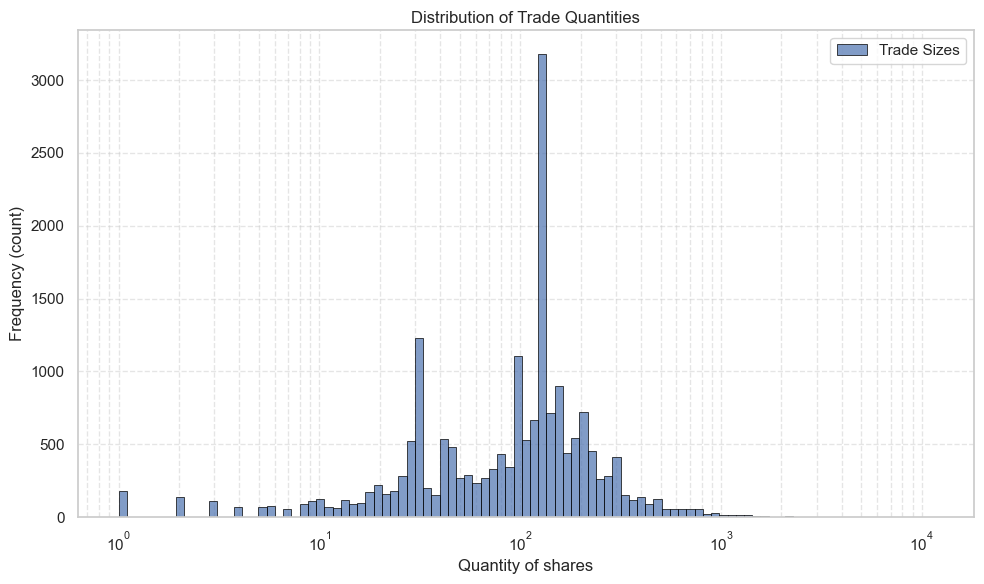

<Axes: title={'center': 'Distribution of Trade Quantities'}, xlabel='Quantity of shares', ylabel='Frequency (count)'>

In [12]:
def plot_qty_hist(df, *, title="Distribution of Trade Quantities", bins=100, log_x=True, label="Trade Sizes"):
    """
    Plot histogram of trade quantities.

    Input
    -----
    df : pd.DataFrame
        Trades dataframe containing a 'qty' column.

    Output
    ------
    Displays the distribution of positive trade quantities.
    """

    # Extract quantity values and remove NaNs / non-positive trades
    qty = df["qty"].to_numpy(dtype=float)
    qty = qty[(np.isfinite(qty)) & (qty > 0)]

    if qty.size == 0:
        print("No valid quantity data found.")
        return

    
    plt.figure(figsize=(10, 6))
    
    # Bins
    hist_bins = bins
    if log_x:
        # Create geometrically spaced bins for the log scale
        hist_bins = np.logspace(np.log10(qty.min()), np.log10(qty.max()), bins)

    # histplot
    ax = sns.histplot(
        data=qty,
        bins=hist_bins,
        color="#4C72B0",
        edgecolor="black",  
        linewidth=0.5,     
        alpha=0.7,
        label=label
    )

    if log_x:
        ax.set_xscale("log")

    # Formatting
    ax.set_xlabel("Quantity of shares")
    ax.set_ylabel("Frequency (count)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()
    return ax


plot_qty_hist(trade, log_x=True)

## 1.2 Tick size :

A naive estimator is the **minimum non-zero price change**:
$
\hat{\tau} = \min\{|\Delta p_i| : |\Delta p_i|>0\}
$
but this is **not robust**: a single **bad print / tape error / outlier** can create an unrealistically small jump and collapse the estimate.

To obtain a stable tick estimate, We use two complementary strategies:

1) **Mode of small moves (bottom 20%)**  
Compute non-zero $|\Delta p|$, keep the **bottom 20% quantile** (to focus on “normal” micro moves), then take the **most frequent** rounded jump:
- protects against large jumps and regime shifts
- rounding reduces float noise

2) **GCD of frequent moves (integerized)**  
Scale deltas to integers (e.g. $\times 10^6$), take the **5 most frequent** jump sizes, and estimate the tick as their **GCD**:
- robust when observed jumps are mostly multiples of the true tick
- validated by the **multiple-of-tick fit rate** (fraction of jumps that are multiples)


In [13]:
def print_tick_summary(res: dict, title: str = "Tick Size Estimation") -> None:
    _print_header(title)

    tick = res.get("tick_est", np.nan)
    fit = res.get("multiple_fit_rate", np.nan)

    print(f"{'Estimated tick':<22}: {tick}")
    
    if not pd.isna(fit):
        print(f"{'Multiple fit rate':<22}: {100*fit:.2f} %")

    if "small_cutoff" in res:
        print(f"{'Small move cutoff':<22}: {res['small_cutoff']}")

    if "n_nonzero_deltas" in res:
        print(f"{'Non-zero price jumps':<22}: {res['n_nonzero_deltas']:,}")

    if "n_samples" in res:
        print(f"{'Samples analysed':<22}: {res['n_samples']:,}")

    if "most_frequent_jump" in res:
        print(f"{'Most frequent jump':<22}: {res['most_frequent_jump']}")

    # Print top deltas table if available
    top = res.get("top_deltas")
    if top:
        print("\nMost frequent deltas")
        print("--------------------")
        print(f"{'delta':<10}{'count'}")
        for d, c in top:
            print(f"{d:<10}{c}")

    print()

In [14]:
def estimate_tick_size_quantile(
    df: pd.DataFrame,
    *,
    rounding_decimals: int = 6,
    top_k: int = 10,
    print_summary: bool = True,
) -> dict:
    """
    Estimate tick size from trade prices using frequent small price changes.
    """

    out = {}

    if len(df) < 2:
        out.update({
            "tick_est": np.nan,
            "n_nonzero_deltas": 0,
            "top_deltas": [],
            "multiple_fit_rate": np.nan
        })
        if print_summary:
            print_tick_summary(out, "Tick Size Estimation (Quantile)")
        return out

    # Absolute non-zero price changes
    d = np.abs(df["price"].diff().to_numpy(dtype=float))
    d = d[~np.isnan(d)]
    d = d[d > 0]

    out["n_nonzero_deltas"] = int(d.size)

    if d.size == 0:
        out.update({
            "tick_est": np.nan,
            "top_deltas": [],
            "multiple_fit_rate": np.nan
        })
        if print_summary:
            print_tick_summary(out, "Tick Size Estimation (Quantile)")
        return out

    # Reduce float noise
    d_rounded = np.round(d, rounding_decimals)

    # Focus on small price moves
    cutoff = np.quantile(d_rounded, 0.20)
    small = d_rounded[d_rounded <= cutoff]
    if small.size == 0:
        small = d_rounded

    # Most frequent small delta = tick estimate
    vals, counts = np.unique(small, return_counts=True)
    tick = float(vals[np.argmax(counts)])

    # Diagnostics: most frequent deltas
    vals_all, counts_all = np.unique(d_rounded, return_counts=True)
    order = np.argsort(counts_all)[::-1]
    top = [(float(vals_all[i]), int(counts_all[i])) for i in order[:top_k]]

    # Check if deltas are multiples of tick
    ratio = d_rounded / tick
    nearest = np.round(ratio)
    ok = np.isclose(ratio, nearest, rtol=1e-4, atol=1e-8)

    out.update({
        "tick_est": tick,
        "top_deltas": top,
        "multiple_fit_rate": float(np.mean(ok)),
        "small_cutoff": float(cutoff)
    })

    if print_summary:
        print_tick_summary(out, "Tick Size Estimation (Quantile)")

    return out



def estimate_tick_size_gcd(
    df: pd.DataFrame,
    precision: int = 10,
    print_summary: bool = True
) -> dict:
    """
    Estimate tick size using the GCD of frequent price jumps.
    """

    prices = df["price"].dropna().to_numpy()
    deltas = np.abs(np.diff(prices))
    deltas = deltas[deltas > 1e-9]

    if len(deltas) == 0:
        res = {"tick_est": np.nan, "confidence": 0}
        if print_summary:
            print_tick_summary(res, "Tick Size Estimation (GCD)")
        return res

    # Convert to integers to avoid float noise
    multiplier = 10**6
    d_int = np.round(deltas * multiplier).astype(np.int64)

    # Unique jumps and frequencies
    vals, counts = np.unique(d_int, return_counts=True)

    order = np.argsort(counts)[::-1]
    vals = vals[order]
    counts = counts[order]

    # GCD of most frequent jumps
    top_n = min(5, len(vals))
    representative = vals[:top_n]

    estimated_tick_int = reduce(gcd, representative)

    tick_est = estimated_tick_int / multiplier

    # Check proportion of multiples
    fit_rate = np.mean((d_int % estimated_tick_int) == 0)

    res = {
        "tick_est": tick_est,
        "multiple_fit_rate": fit_rate,
        "most_frequent_jump": vals[0] / multiplier,
        "n_samples": len(deltas),
    }

    if print_summary:
        print_tick_summary(res, "Tick Size Estimation (GCD)")

    return res

In [15]:
tick_quant = estimate_tick_size_quantile(trade);
tick_gcd = estimate_tick_size_gcd(trade);
TICKSIZE = min(float(tick_quant["tick_est"]), float(tick_gcd["tick_est"]))


Tick Size Estimation (Quantile)
───────────────────────────────
Estimated tick        : 0.01
Multiple fit rate     : 100.00 %
Small move cutoff     : 0.01
Non-zero price jumps  : 2,834

Most frequent deltas
--------------------
delta     count
0.01      2606
0.02      191
0.03      27
0.04      9
0.05      1


Tick Size Estimation (GCD)
──────────────────────────
Estimated tick        : 0.01
Multiple fit rate     : 100.00 %
Samples analysed      : 2,834
Most frequent jump    : 0.01



Both method output the same ticksize. Hence, we could confirm the value of our ticksize.

## 1.3 Intraday activity

We are going to measure trading activity over calendar time for a single stock–day.

Trades are aggregated into fixed-width time bins (e.g. 5 minutes) to capture
intraday intensity and liquidity patterns.

**Per-bin metrics**
- n_trades: number of trades
- volume: total traded quantity
- notional: total traded value (price × quantity)
- vwap: volume-weighted average price
- last_price: last traded price in the bin

In [16]:
def intraday_activity(df: pd.DataFrame, *, bin_size: str = "5min") -> pd.DataFrame:
    """
    Compute intraday activity curves for ONE stock-day.

    Input
    -----
    df : pd.DataFrame
        Trades dataframe containing columns: 'ts', 'price', 'qty'.

    Output
    ------
    DataFrame indexed by time bins with:
        n_trades, volume, notional, vwap, last_price.

    Notes
    -----
    The resulting dataframe is designed to feed plotting functions
    such as `plot_volume_hist`.
    """

    if len(df) == 0:
        return pd.DataFrame(columns=["n_trades", "volume", "notional", "vwap", "last_price"])

    # Prepare clean time-indexed dataframe
    d = df[["ts", "price", "qty"]].copy()
    d["ts"] = pd.to_datetime(d["ts"], errors="coerce")
    d = d.dropna(subset=["ts", "price", "qty"]).set_index("ts").sort_index()

    # Aggregate core activity measures per time bin
    n_trades = d["price"].resample(bin_size).count().rename("n_trades")
    volume = d["qty"].resample(bin_size).sum().rename("volume")
    notional = (d["price"] * d["qty"]).resample(bin_size).sum().rename("notional")

    # Volume-weighted average price
    vwap = (notional / volume).rename("vwap").where(volume > 0)

    # Last trade price in each bin
    last_price = d["price"].resample(bin_size).last().rename("last_price")

    out = pd.concat([n_trades, volume, notional, vwap, last_price], axis=1)

    return out

daily_intraday_activity = intraday_activity(trade, bin_size = "5min")

In [17]:
def plot_volume_hist(df, *, title="Trade Volume Evolution", color="steelblue", label="Volume per bin"):
    """
    Plot trade volume over time using the intraday activity dataframe.

    Input
    -----
    df : pd.DataFrame
        Output of `intraday_activity()` containing a 'volume' column
        indexed by time bins.

    Output
    ------
    Displays the volume traded in each time bin.
    """

    if df.empty:
        print("Dataframe is empty.")
        return

    plt.figure(figsize=(12, 6))

    # Estimate bin width from index spacing
    try:
        bin_width = df.index.to_series().diff().median()
    except Exception:
        bin_width = pd.Timedelta(minutes=1)

    # Bar plot with visible bin edges
    plt.bar(
        df.index,
        df["volume"],
        width=bin_width,
        color=color,
        edgecolor="black",   
        linewidth=0.5,
        alpha=0.85,
        label=label,
    )

    plt.xlabel("Time")
    plt.ylabel("Volume (Number of shares)")
    plt.title(title)

    plt.legend()

    # Grid only on volume axis
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

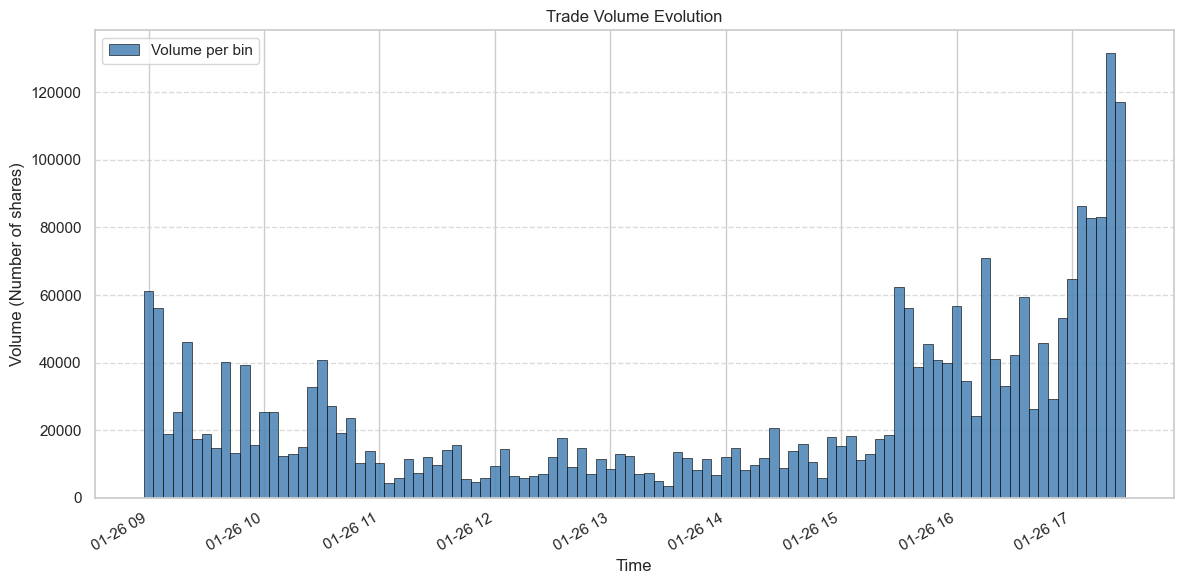

In [18]:
plot_volume_hist(daily_intraday_activity)

We recognize the U shape discussed in class.

## 1.4 Volatility and Traded Volume

We measure the intraday relationship between trading activity and price variability using fixed time bins (e.g. 1 minute).

**Returns.**  
Trades are resampled by bin and the last price \(P_t\) is kept. Log returns are computed within each day to avoid overnight jumps:
$
r_t = \log P_t - \log P_{t-1}.
$

**Volatility proxy.**  
Per-bin volatility is defined as
$
\text{vol}_t = r_t^2 \quad \text{or} \quad \text{vol}_t = |r_t|.
$

**Activity.**  
For each bin we compute an activity variable
$
x_t \in \{\text{volume}, \text{notional}\}.
$

**Cleaning.**  
We align $ (x_t, \text{vol}_t) $, remove missing values and empty bins, and keep only days with enough observations.

**Metrics.**  
We report:
- Pearson correlation $ \rho(x_t, \text{vol}_t) $ that represents the  correlation between the volatility and traded volume.
- Spearman correlation that represents the potential monotonic relationship between the volatility and traded volume.
- Log--log Pearson correlation
$
\rho\!\left(\log x_t, \log \text{vol}_t\right),
$
which tests a scaling relation $ \text{vol}_t \propto x_t^\alpha $.

A positive correlation indicates that higher trading activity coincides with higher intraday volatility.


Before diving into the statistical hypothesis, let's display the plot. 

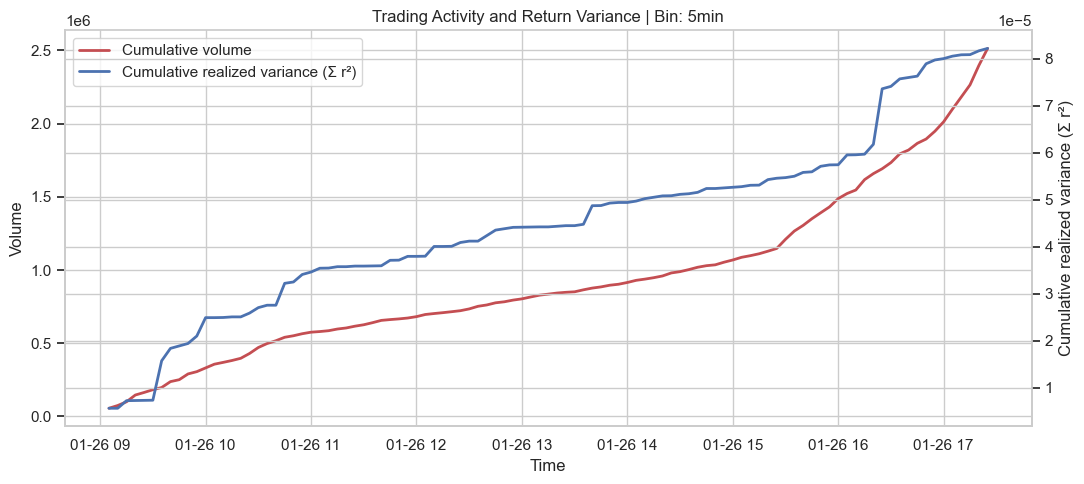

In [19]:
def binned_lastprice_returns(df: pd.DataFrame, *, bin_size: str = "1min") -> pd.Series:
    """
    Compute log returns of the last traded price in each time bin.

    Input
    -----
    df : pd.DataFrame
        Trades dataframe containing columns: 'ts', 'price'.

    Output
    ------
    pd.Series
        Log returns indexed by bin time.

    Notes
    -----
    Returns are computed separately within each day to avoid
    overnight jumps between consecutive trading days.
    """
    if len(df) == 0:
        return pd.Series(dtype=float)

    # Prepare clean time-indexed price series
    d = df[["ts", "price"]].copy()
    d["ts"] = pd.to_datetime(d["ts"], errors="coerce")
    d = d.dropna(subset=["ts", "price"]).set_index("ts").sort_index()

    # Last traded price in each calendar-time bin
    last_p = d["price"].resample(bin_size).last()

    # Log returns computed day by day
    log_p = np.log(last_p)
    r = log_p.groupby(log_p.index.date).diff()

    r.name = "ret"
    return r

    
def plot_activity_and_variance(
    df,
    bin_size="5min",
    activity_col="n_trades",
    vol_proxy="sq_ret",
    var_mode="cumsum",
):
    """
    Plot cumulative trading activity and return variation through the day.

    Input
    -----
    df : pd.DataFrame
        Trades dataframe used to compute intraday activity and binned returns.

    Output
    ------
    Displays a two-axis plot:
        - left axis: cumulative activity
        - right axis: cumulative or running return variation
    """


    # Activity per bin
    act = intraday_activity(df, bin_size=bin_size)
    if activity_col not in act.columns:
        raise ValueError(f"{activity_col=} not in intraday_activity output")

    a = act[activity_col].dropna()

    # Returns per bin
    r = binned_lastprice_returns(df, bin_size=bin_size).dropna()

    # Volatility proxy
    if vol_proxy == "sq_ret":
        v = (r**2).rename("vol")
    elif vol_proxy == "abs_ret":
        v = r.abs().rename("vol")
    else:
        raise ValueError("vol_proxy must be 'sq_ret' or 'abs_ret'")

    # Align the two series
    joined = pd.concat([a.rename("act"), v], axis=1).dropna()

    # Curves
    act_curve = joined["act"].cumsum()

    if var_mode == "cumsum":
        var_curve = joined["vol"].cumsum()
        var_label = "Cumulative realized variance (Σ r²)"
    else:
        var_curve = joined["vol"].expanding().mean()
        var_label = "Running variance proxy (mean r²)"

    # Plot
    fig, ax1 = plt.subplots(figsize=(11, 5))

    ax1.plot(
        act_curve.index,
        act_curve.values,
        color=sns.color_palette()[3],
        linewidth=2,
        label=f"Cumulative {activity_col.replace('_',' ')}",
    )

    ax1.set_ylabel(activity_col.replace("_", " ").title())

    ax2 = ax1.twinx()

    ax2.plot(
        var_curve.index,
        var_curve.values,
        color=sns.color_palette()[0],
        linewidth=2,
        label=var_label,
    )

    ax2.set_ylabel(var_label)

    ax1.set_title(f"Trading Activity and Return Variance | Bin: {bin_size}")
    ax1.set_xlabel("Time")

    # Merge legends
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    sns.despine(ax=ax1, right=False)

    plt.tight_layout()
    plt.show()


plot_activity_and_variance(
    trade,
    bin_size="5min",
    activity_col="volume",   
    vol_proxy="sq_ret",
    var_mode="cumsum"         
)

Now, let's verify statistically if there is trully a link between volume and volatility :



When analyzing the relationship between variables, we compare **Pearson** and **Spearman** coefficients to understand the nature of the association (linear vs. monotonic) and the influence of outliers.

---

### 1. Pearson Correlation ($r$)
* **Focus:** Measures **linear** relationships.
* **Sensitivity:** Highly sensitive to the magnitude of values and outliers.
* **Assumption:** Assumes data is normally distributed and the relationship is a straight line.
* **Formula Concept:** $$r = \frac{\text{cov}(X, Y)}{\sigma_X \sigma_Y}$$

### 2. Spearman Correlation ($\rho$)
* **Focus:** Measures **monotonic** relationships (whether variables move together, even if not at a constant rate).
* **Sensitivity:** Robust to outliers because it operates on the **rank** of the data points rather than their raw values.
* **Assumption:** None regarding distribution; works well for ordinal data.
* **Formula Concept:** $$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$



We calculate both metrics simultaneously to gain deeper insights into the dataset:


 **Rule:** > * $r > \rho$: Relationship is strictly linear and data is clean.
* $\rho > r$: Relationship is monotonic but non-linear, or outliers are present.


**Hypothesis Testing for Correlation**

To determine if the observed relationships are statistically significant and not just due to random noise, we perform hypothesis testing on both coefficients.

### 1. Pearson Linear Correlation Test
**Goal:** Evaluate the significance of the **linear** relationship.

* **Null Hypothesis ($H_0$):** $r = 0$ (No linear correlation exists).
* **Alternative Hypothesis ($H_1$):** $r \neq 0$ (A significant linear correlation exists).

**Test Statistic Calculation:**
Using the t-distribution with $df = n - 2$:
$$t = r \sqrt{\frac{n-2}{1-r^2}}$$

**Result:** The calculated **p-value = 0.4** 

---

### 2. Spearman Rank Correlation Test
**Goal:** Evaluate the significance of the **monotonic** (ranked) relationship.

* **Null Hypothesis ($H_0$):** $\rho = 0$ (No monotonic association exists).
* **Alternative Hypothesis ($H_1$):** $\rho \neq 0$ (A significant monotonic association exists).

**Test Statistic Calculation:**
For samples $n > 10$, we use:
$$t = \rho \sqrt{\frac{n-2}{1-\rho^2}}$$

**Result:** The calculated **p-value = 0.01** 

---

### 💡 Interpretation & Decision Rule

**Statistical Decision:**
* If **$p < 0.05$** (or $|t| > t_{critical}$): We **reject $H_0$**. 
* If **$p \ge 0.05$** (or $|t| \le t_{critical}$): We **fail to reject $H_0$**. Any observed correlation is likely due to random chance.


In [20]:
def print_vol_volume_summary(res: dict, title: str = "Volatility–Volume Link") -> None:
    _print_header(title)

    print(f"{'Bin size':<24}: {res.get('bin_size')}")
    print(f"{'Volume measure':<24}: {res.get('volume_measure')}")
    print(f"{'Volatility proxy':<24}: {res.get('vol_proxy')}")
    print(f"{'Bins used':<24}: {res.get('n_bins_used'):,}")

    print("\nCorrelations")
    print("------------")

    if "pearson_corr" in res:
        print(f"{'Pearson corr':<24}: {res.get('pearson_corr'):.4f}")
        print(f"{'Pearson p-value':<24}: {res.get('pearson_pvalue'):.3g}")

    if "spearman_corr" in res:
        print(f"{'Spearman corr':<24}: {res.get('spearman_corr'):.4f}")
        print(f"{'Spearman p-value':<24}: {res.get('spearman_pvalue'):.3g}")

    if "pearson_corr_loglog" in res:
        print(f"{'Log–log Pearson corr':<24}: {res.get('pearson_corr_loglog'):.4f}")
        print(f"{'Log–log p-value':<24}: {res.get('loglog_pvalue'):.3g}")

    print()


def vol_volume_link(
    df: pd.DataFrame,
    *,
    bin_size: str = "1min",
    use: str = "volume",
    vol_proxy: str = "sq_ret",
    min_bins: int = 30,
    eps: float = 1e-16,
    print_summary: bool = True,
) -> dict:
    """
    Compute volatility-volume link for ONE stock-day.
    
    Inputs:
      df: cleaned trades df
      activity: output of intraday_activity(df, bin_size)
    Output:
      dict with correlations and counts
    """
    out = {}

    # 1) returns on same bins
    activity = intraday_activity(df,bin_size=bin_size)
    r = binned_lastprice_returns(df, bin_size=bin_size)

    # 2) volatility proxy per bin
    if vol_proxy == "sq_ret":
        v = (r ** 2).rename("vol")
    elif vol_proxy == "abs_ret":
        v = (r.abs()).rename("vol")
    else:
        raise ValueError("vol_proxy must be 'sq_ret' or 'abs_ret'")

    # 3) choose volume measure
    if use not in activity.columns:
        raise ValueError(f"activity must contain column '{use}'. Got {list(activity.columns)}")
    x = activity[use].rename(use)

    # 4) align and drop NaNs / empty bins
    joined = pd.concat([x, v], axis=1).dropna()
   
    joined = joined[(joined[use] > 0) & (joined["vol"] >= 0)]

    out["n_bins_used"] = int(len(joined))
    out["bin_size"] = bin_size
    out["vol_proxy"] = vol_proxy
    out["volume_measure"] = use


    if len(joined) < min_bins:
        out["pearson_corr"] = np.nan
        out["spearman_corr"] = np.nan
        out["pearson_corr_loglog"] = np.nan
        return out

    # 5) correlations
    corr_p, pval_p = pearsonr(joined[use], joined["vol"])
    out["pearson_corr"] = float(corr_p)
    out["pearson_pvalue"] = float(pval_p)

    corr_s, pval_s = spearmanr(joined[use], joined["vol"])
    out["spearman_corr"] = float(corr_s)
    out["spearman_pvalue"] = float(pval_s)

    log_x = np.log(joined[use])
    log_v = np.log(joined["vol"] + eps)
    corr_l, pval_l = pearsonr(log_x, log_v)
    out["pearson_corr_loglog"] = float(corr_l)
    out["loglog_pvalue"] = float(pval_l)

    if print_summary:
        print_vol_volume_summary(out)


    return out


volatility_volume_link = vol_volume_link(trade,bin_size="5min")


Volatility–Volume Link
──────────────────────
Bin size                : 5min
Volume measure          : volume
Volatility proxy        : sq_ret
Bins used               : 101

Correlations
------------
Pearson corr            : 0.0833
Pearson p-value         : 0.408
Spearman corr           : 0.2491
Spearman p-value        : 0.012
Log–log Pearson corr    : 0.2777
Log–log p-value         : 0.00493



**Final Conclusion:**
The analysis reveals a **significant monotonic relationship** between the variables, despite a **non-significant linear relationship**. 

Because the Spearman correlation ($0.249$) is much higher and statistically significant compared to the Pearson correlation ($0.083$), we can conclude that the relationship between these variables is **non-linear**. The variables tend to move in the same direction, but the rate of change is not constant, or the data contains outliers that have heavily penalized the Pearson metric. 

Furthermore, the **Log-Log Pearson correlation ($0.277$, $p < 0.01$)** confirms that the relationship is much stronger when viewed through a power-law or exponential lens, rather than a simple linear one.

## 1.5 High frequency log-returns

**version 1 :** We start by a simple approximation of the log-returns distribution, without grouping the prices that occurs on the same timestamps that could bias the returns toward 0.


In [21]:
def event_time_returns(df: pd.DataFrame, *, step: int = 1) -> np.ndarray:
    """
    Event-time log returns.
    
    step=1  → every trade
    step=5  → every 5th trade, etc.
    """
    if len(df) <= step:
        return np.array([])

    prices = df["price"].to_numpy(dtype=float)

    # sample every `step` trades
    sampled = prices[::step]

    # log returns in event time
    r = np.diff(np.log(sampled))

    return r


def calendar_time_returns(df: pd.DataFrame, *, freq: str = "1min"):
    """
    Calendar-time log returns with interval weights.

    Returns:
      r      : array of log returns
      w      : array of weights (interval lengths in seconds)
    """
    if len(df) == 0:
        return np.array([]), np.array([])

    d = df[["ts", "price"]].copy().set_index("ts").sort_index()

    # last traded price on regular grid
    p = d["price"].resample(freq).last()

    # log returns
    logp = np.log(p)
    r = logp.diff()

    # weights = length of each interval (seconds)
    dt = p.index.to_series().diff().dt.total_seconds()

    # drop NaNs
    mask = (~r.isna()) & (~dt.isna())
    r = r[mask].to_numpy(dtype=float)
    w = dt[mask].to_numpy(dtype=float)

    return r, w

def weighted_return_stats(r: np.ndarray, w: np.ndarray) -> dict:
    """
    Compute weighted moments for calendar-time returns.
    """
    out = {}
    if len(r) == 0:
        out["var"] = np.nan
        out["std"] = np.nan
        out["mean"] = np.nan
        out["kurtosis"] = np.nan
        return out

    w = w / np.sum(w)  # normalize weights

    mean = np.sum(w * r)
    var = np.sum(w * (r - mean) ** 2)
    std = np.sqrt(var)

    # weighted kurtosis
    kurt = np.sum(w * (r - mean) ** 4) / (var ** 2) if var > 0 else np.nan

    out["mean"] = float(mean)
    out["var"] = float(var)
    out["std"] = float(std)
    out["kurtosis"] = float(kurt)

    return out

,mean,var,std,kurtosis,freq
0,0.000023,2.304681e-07,0.000480,5.100873,1min
1,0.000125,7.976574e-07,0.000893,5.012955,5min
2,0.000312,2.575825e-06,0.001605,3.927073,15min
3,0.000157,7.274236e-06,0.002697,2.698550,60min


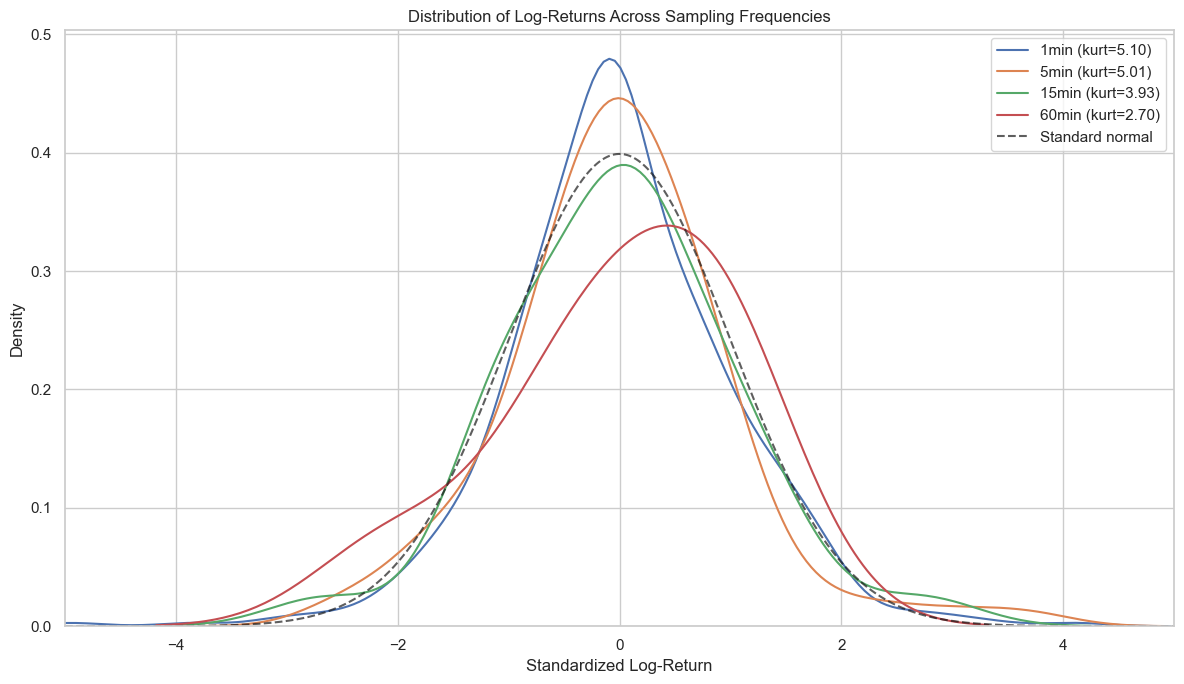

In [22]:
def plot_return_distributions(df, frequencies=("1min", "5min", "15min", "60min")):
    """
    Plot standardized calendar-time return distributions across sampling
    frequencies and compare them with a standard normal benchmark.

    Returns a DataFrame containing weighted summary statistics for each
    frequency.
    """
    plt.figure(figsize=(12, 7))

    stats_list = []
    x = np.linspace(-5, 5, 500)

    for freq in frequencies:
        r, w = calendar_time_returns(df, freq=freq)

        if len(r) < 2 or np.sum(w) == 0:
            continue

        stats = weighted_return_stats(r, w)
        mean = stats["mean"]
        var = stats["var"]

        if not np.isfinite(var) or var <= 0:
            continue

        std_r = (r - mean) / np.sqrt(var)

        sns.kdeplot(
            std_r,
            bw_adjust=1.0,
            fill=False,
            clip=(-5, 5),
            label=f"{freq} (kurt={stats['kurtosis']:.2f})",
        )

        stats["freq"] = freq
        stats_list.append(stats)

    plt.plot(x, norm.pdf(x), "k--", alpha=0.7, label="Standard normal")

    plt.title("Distribution of Log-Returns Across Sampling Frequencies")
    plt.xlabel("Standardized Log-Return")
    plt.ylabel("Density")
    plt.xlim(-5, 5)
    plt.legend()
    plt.tight_layout()

    return pd.DataFrame(stats_list)

plot_return_distributions(trade)

**Comments**

At very high sampling frequencies (e.g., 1-minute), the distribution of log-returns is sharply peaked around zero and exhibits fat tails. Most minute-to-minute price changes are very small because prices do not move much over short intervals. However, occasional bursts of trading activity, order-flow imbalances, or information arrivals generate relatively large price changes, which create heavy tails. In addition, volatility varies over time (volatility clustering), so returns are effectively drawn from a mixture of distributions with different variances, which mechanically increases kurtosis.

As the sampling interval increases (e.g., 15-minute or 60-minute returns), each return becomes the sum of many smaller shocks. Microstructure noise and very small price changes partially cancel out, and volatility regimes are averaged over longer periods. By the Central Limit Theorem, this aggregation pushes the distribution closer to a normal distribution, reducing excess kurtosis. Therefore, return distributions become less peaked and less heavy-tailed as the sampling frequency decreases.


**version 2 :** We decided to groupby the prices that occurs on the same timestamps as to avoid to bias the returns toward 0.

In [23]:
def group_by_tolerance(df, tolerance="1s", price_col="price", qty_col="qty", ts_col="ts",
                          method="vwap"):
    """
    Collapse multiple rows into tolerance-sized time buckets.
    tolerance examples: "1s", "100ms", "500ms", "1min"
    method: "mean" or "vwap"
    """
    d = df[[ts_col, price_col, qty_col]].copy()
    d[ts_col] = pd.to_datetime(d[ts_col], utc=True, errors="coerce")
    d = d.dropna(subset=[ts_col, price_col]).sort_values(ts_col)

    if method == "mean":
        out = (
            d.set_index(ts_col)
             .groupby(pd.Grouper(freq=tolerance))[price_col]
             .mean()
             .dropna()
             .to_frame("price")
        )
    elif method == "vwap":
        d = d.set_index(ts_col)
        def _vwap(g):
            q = g[qty_col].to_numpy()
            p = g[price_col].to_numpy()
            # if qty missing/zero, fallback to mean
            if np.nansum(q) <= 0:
                return np.nanmean(p)
            return np.nansum(p * q) / np.nansum(q)

        out = (
            d.groupby(pd.Grouper(freq=tolerance))
             .apply(_vwap)
             .dropna()
             .to_frame("price")
        )
    else:
        raise ValueError("method must be 'mean' or 'vwap'")

    out = out.reset_index().rename(columns={ts_col: "ts"})
    return out

/var/folders/wd/xzhz26212j9cpdrvtc4cjt500000gn/T/ipykernel_12663/2993499732.py:27: RuntimeWarning: Mean of empty slice
  return np.nanmean(p)


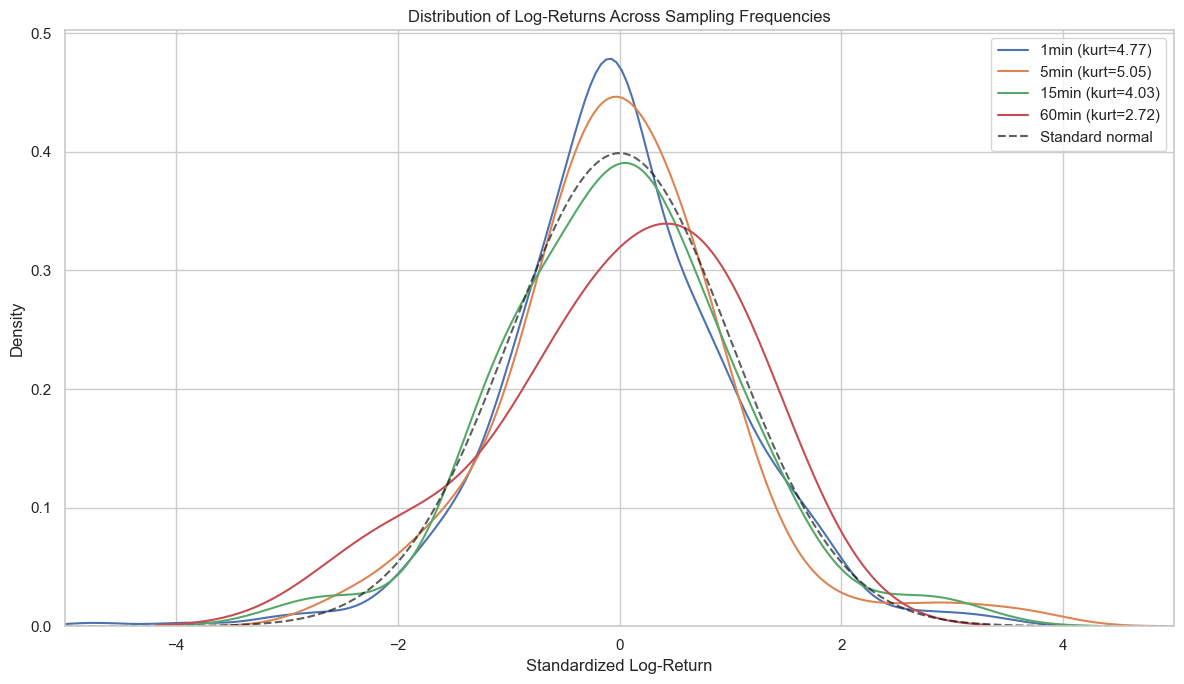

In [24]:
trade_clean = group_by_tolerance(trade, tolerance="1s", method="vwap")
stats_trade_clean = plot_return_distributions(trade_clean, frequencies=["1min","5min","15min","60min"])

**Comments**

The kurtosis of this new plot is quite similar to the plot before. Hence, we could say that the first simple approach works well.


# Question 2

## 2.1 General statistics for updates dataset

We are going to display some general statistics : 

**Basic information**
- n_rows, n_cols: dataset dimensions  
- ts_min, ts_max: first and last timestamps  
- span_seconds: total time coverage in seconds  

**Opening and activity**
- opening_time: first timestamp where both bid and ask are present  
- empty OLB in activity in %: fraction of updates after the open where both bid and ask are missing  

**Missing data ratios**
- missing ap %, missing bp %, missing aq %, missing bq %: percentage of missing values for best prices and quantities  

**Inter-update timing (ms)**
- n_duplicate_ts: number of zero time differences (duplicate timestamps)  
- dt_median_ms: median inter-update duration  
- dt_p90_ms, dt_p99_ms: high quantiles of inter-update durations  
- dt_max_ms: maximum observed gap  

**Price statistics**
- ap_min, ap_median, ap_max: summary stats for best ask price  
- bp_min, bp_median, bp_max: summary stats for best bid price  
- Is spread positif: whether the bid–ask spread is always non-negative  

**Trade and iceberg indicators**
- total_trades: number of trade updates (type = T)  
- ask_icebergs_count, bid_icebergs_count: detected iceberg-like events  
- ask_iceberg_ratio, bid_iceberg_ratio: fraction of trades flagged as iceberg-like

In [25]:
def _print_kv(data: dict, width: int = 28) -> None:
    for k, v in data.items():
        print(f"{k:<{width}} {v}")


def updates_stats(df: pd.DataFrame) -> None:
    if df.empty:
        print("DataFrame is empty")
        return

    df = df.copy()
    df["ts"] = pd.to_datetime(df["ts"])
    df = df.sort_values("ts").reset_index(drop=True)

    # -------------------------
    # Basic information
    # -------------------------
    n_rows, n_cols = df.shape
    ts_min, ts_max = df["ts"].iloc[0], df["ts"].iloc[-1]

    _print_header("Basic information")
    _print_kv({
        "n_rows": n_rows,
        "n_cols": n_cols,
        "ts_min": ts_min,
        "ts_max": ts_max,
        "span_seconds": (ts_max - ts_min).total_seconds()
    })

    # -------------------------
    # Opening and activity
    # -------------------------
    valid_mask = df["bp"].notna() & df["ap"].notna()

    if valid_mask.any():
        opening_ts = df.loc[valid_mask, "ts"].iloc[0]
        olb = df[df["ts"] >= opening_ts]
        empty_ratio = (olb["ap"].isna() & olb["bp"].isna()).mean()
    else:
        opening_ts = None
        empty_ratio = 1.0

    _print_header("Opening and activity")
    _print_kv({
        "opening_time": opening_ts,
        "empty OLB in activity (%)": f"{empty_ratio:.2%}"
    })

    # -------------------------
    # Missing values
    # -------------------------
    miss = {}
    for col in ["ap", "bp", "aq", "bq"]:
        if col in df.columns:
            miss[f"missing {col} (%)"] = f"{df[col].isna().mean():.2%}"

    _print_header("Missing data ratios")
    _print_kv(miss)

    # -------------------------
    # Inter-update timing
    # -------------------------
    dt = df["dt"] if "dt" in df.columns else df["ts"].diff()
    dt_ms = dt.dt.total_seconds().to_numpy() * 1000 if hasattr(dt, "dt") else dt.to_numpy()
    dt_ms = dt_ms[~np.isnan(dt_ms)]

    timing = {
        "n_duplicate_ts": int(np.sum(dt_ms == 0)) if dt_ms.size else 0
    }

    if dt_ms.size:
        timing.update({
            "dt_median_ms": float(np.median(dt_ms)),
            "dt_p90_ms": float(np.percentile(dt_ms, 90)),
            "dt_p99_ms": float(np.percentile(dt_ms, 99)),
            "dt_max_ms": float(np.max(dt_ms)),
        })

    _print_header("Inter-update timing (ms)")
    _print_kv(timing)

    # -------------------------
    # Price statistics
    # -------------------------
    price_stats = {}

    for col in ["ap", "bp"]:
        vals = df[col].to_numpy(dtype=float)
        if not np.all(np.isnan(vals)):
            price_stats[f"{col}_min"] = float(np.nanmin(vals))
            price_stats[f"{col}_median"] = float(np.nanmedian(vals))
            price_stats[f"{col}_max"] = float(np.nanmax(vals))
        else:
            price_stats[f"{col}_min"] = np.nan
            price_stats[f"{col}_median"] = np.nan
            price_stats[f"{col}_max"] = np.nan

    df["spread"] = df["ap"] - df["bp"]
    price_stats["spread_positive"] = not (df["spread"].round(4) < 0).any()

    _print_header("Price statistics")
    _print_kv(price_stats)

updates_stats(update)



Basic information
─────────────────
n_rows                       226217
n_cols                       6
ts_min                       2026-01-26 09:00:00.340497
ts_max                       2026-01-26 17:29:59.615517
span_seconds                 30599.27502

Opening and activity
────────────────────
opening_time                 2026-01-26 09:00:27.018202
empty OLB in activity (%)    0.00%

Missing data ratios
───────────────────
missing ap (%)               0.04%
missing bp (%)               0.04%
missing aq (%)               0.00%
missing bq (%)               0.00%

Inter-update timing (ms)
────────────────────────
n_duplicate_ts               9622
dt_median_ms                 0.074
dt_p90_ms                    281.1565
dt_p99_ms                    2594.350750000001
dt_max_ms                    20939.485

Price statistics
────────────────
ap_min                       54.87
ap_median                    55.41
ap_max                       55.75
bp_min                       54.83
bp_median

Let's display the poucentage of traded operation in our OLB dataset.

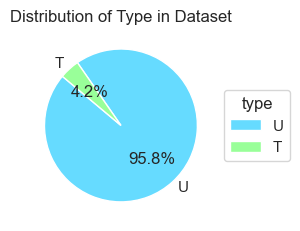

In [26]:
def plot_pie(df, column_name: str):
    
    plt.figure(figsize=(3, 3))

    counts = df[column_name].value_counts()
    counts.plot(
        kind='pie', 
        autopct='%1.1f%%',     
        startangle=140,         
        shadow=False, 
        colors=["#66dbff", '#99ff99', "#99ffd1", "#ffcc99", "#ffb3e6"] 
    )


    plt.title(f'Distribution of {column_name.capitalize()} in Dataset')
    plt.legend(counts.index, title=column_name, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.ylabel('') 
    plt.tight_layout()
    plt.show()

plot_pie(update, "type")

We lightly preprocess the updates dataset and add standard microstructure features.

- Convert timestamps to datetime.
- Optionally remove invalid rows:
  - missing bid/ask prices or sizes,
  - non-positive quantities,
  - crossed quotes (\(ap < bp\)).

We then compute derived features:
$
\text{mid} = \frac{ap + bp}{2}, \quad
\text{spread} = ap - bp,
$
$
\text{imbalance} = \frac{bq - aq}{bq + aq}, \quad
\text{wmid} = \frac{ap \cdot bq + bp \cdot aq}{aq + bq}.
$

In [27]:
def prepare_updates(df: pd.DataFrame, *, drop_bad_rows: bool = False, ticksize: float):
    """
    Clean order book updates and compute basic microstructure features.

    Adds:
    - mid price
    - bid–ask spread
    - order book imbalance
    - weighted mid price
    """
    
    df = df.copy()
    df['ts'] = pd.to_datetime(df['ts'])

    if drop_bad_rows:
        df = df.dropna(subset=["bp", "ap", "bq", "aq"])
        df = df[(df["bq"] > 0) & (df["aq"] > 0)]
        df = df[df["ap"] >= df["bp"]]

    df["mid"] = (df["ap"]+df["bp"])/2
    df["spread"] = df["ap"] - df["bp"]
    df["imbalance"] = (df["bq"]-df["aq"])/(df["bq"]+df["aq"])
    df["wmid"] = (df["ap"]*df["bq"] + df["bp"]*df["aq"])/(df["aq"] + df["bq"])
    
    return df

update = prepare_updates(update, ticksize = TICKSIZE)

## 2.2 Ploting the prices

Displays the temporal evolution of top-of-book prices (bid, ask, mid, weighted mid) on the 5 minute window '2026-01-26 10:00:00' -> '2026-01-26 10:05:00'.

**PLEASE** change the window depending on the trading day you are working on.

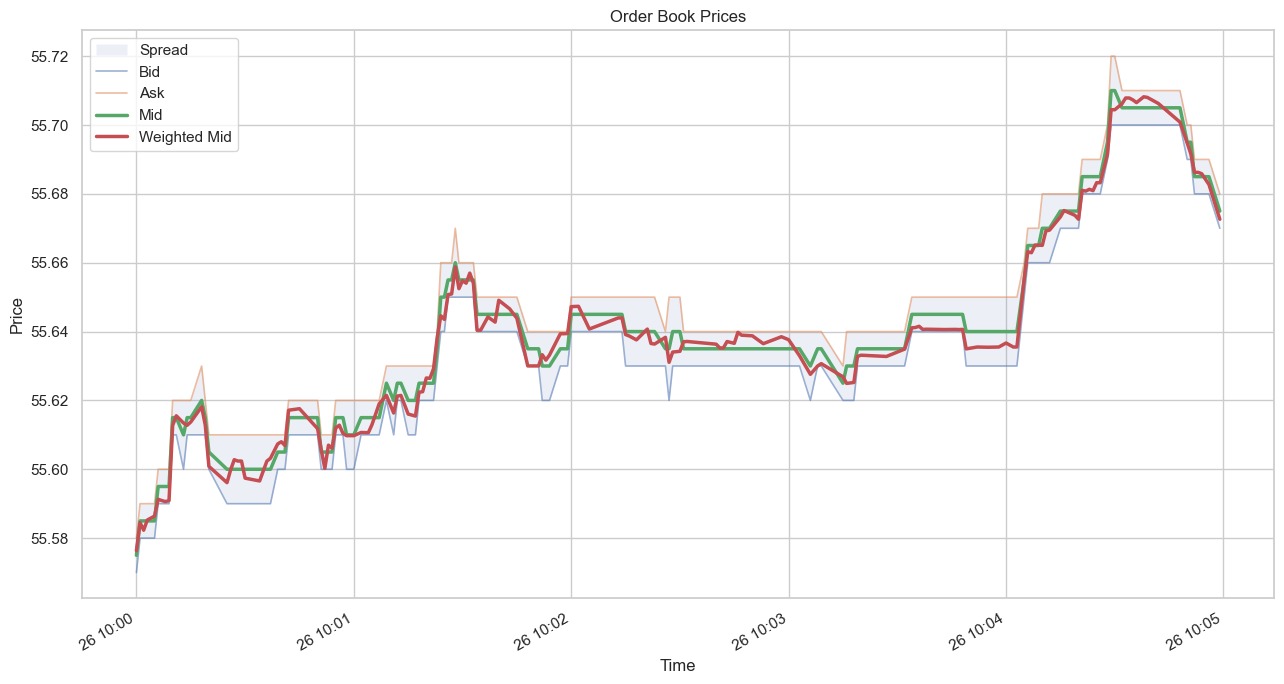

In [28]:
def plot_OLB(df, freq="1S"):
    """
    Plot bid, ask, mid, and weighted mid prices on a regular time grid.

    Bid and ask are shown lightly, while mid and weighted mid are emphasized.
    """

    d = df.copy()
    d["ts"] = pd.to_datetime(d["ts"])
    d = d.set_index("ts").sort_index()
    d = d.resample(freq).last()
    d = d.dropna(subset=["ap", "bp", "mid", "wmid"])

    if d.empty:
        raise ValueError("No valid data available after resampling and filtering.")

    fig, ax = plt.subplots(figsize=(13, 7))

    # Spread band
    ax.fill_between(
        d.index,
        d["bp"].to_numpy(),
        d["ap"].to_numpy(),
        alpha=0.10,
        label="Spread"
    )

    # Order book levels
    sns.lineplot(x=d.index, y=d["bp"], ax=ax, linewidth=1.2, alpha=0.55, label="Bid")
    sns.lineplot(x=d.index, y=d["ap"], ax=ax, linewidth=1.2, alpha=0.55, label="Ask")
    sns.lineplot(x=d.index, y=d["mid"], ax=ax, linewidth=2.5, label="Mid")
    sns.lineplot(x=d.index, y=d["wmid"], ax=ax, linewidth=2.5, label="Weighted Mid")

    ax.set_title("Order Book Prices")
    ax.set_xlabel("Time")
    ax.set_ylabel("Price")
    ax.legend(frameon=True)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

update_window = update[update['ts'].between('2026-01-26 10:00:00', '2026-01-26 10:05:00')] # code line to increment
plot_OLB(update_window, freq = "1s")

## 2.3 Empirical distribution of the spreads

**Note :** 
We needed to round our prices to avoid any miscalculation

### 2.3.1 Event time

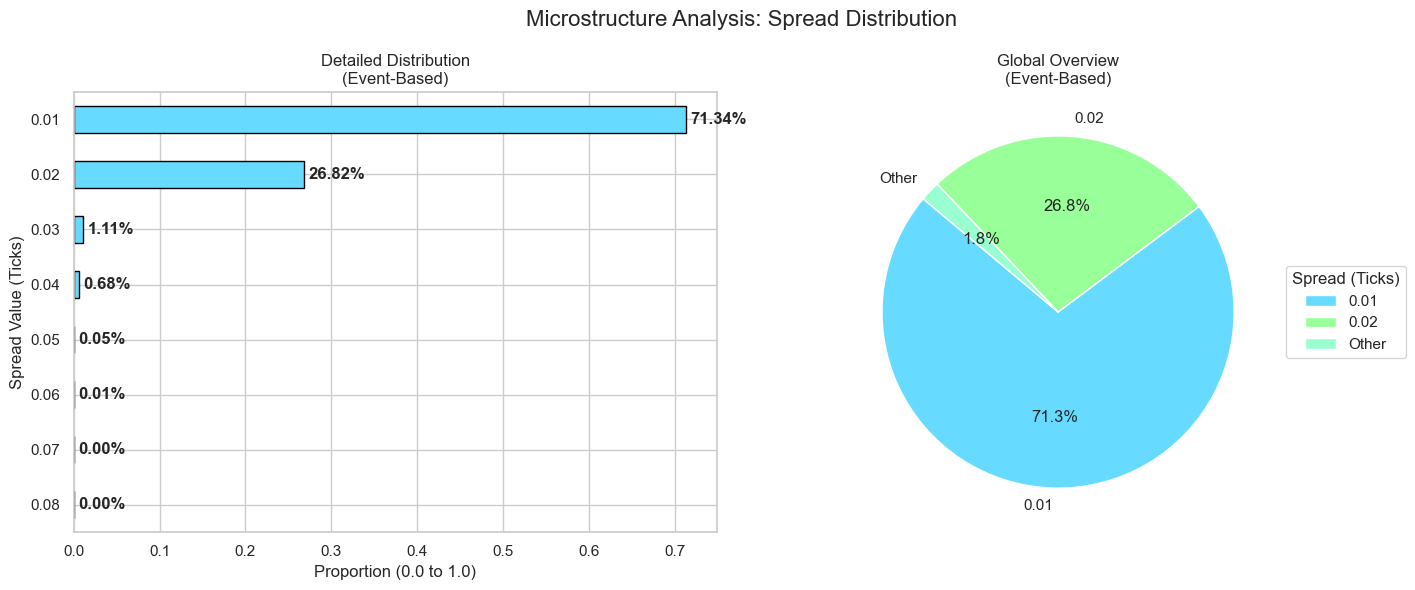

In [29]:
def plot_spread_dist(df: pd.DataFrame, ticksize, calendar_time=False, freq='1min'):
    """
    Plot the spread distribution with a detailed bar chart and a grouped pie chart.
    """
    if calendar_time:
        # We use .last() 
        data_to_plot = df.set_index("ts")["spread"].resample(freq).last().dropna()
        analysis_label = f"Calendar Time (Last value, Freq: {freq})"
    else:
        data_to_plot = df["spread"].dropna()
        analysis_label = "Event-Based"

    # Normalize the distribution
    event_dist = data_to_plot.round(2).value_counts(normalize=True).sort_index()

    # Pie chart grouping logic
    threshold = 2 * ticksize
    mask = event_dist < threshold
    pie_data = event_dist[~mask].copy()
    if event_dist[mask].sum() > 0:
        pie_data['Other'] = event_dist[mask].sum()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Bar Chart 
    event_dist.plot(kind='barh', ax=ax1, color='#66dbff', edgecolor='black')
    ax1.set_title(f'Detailed Distribution\n({analysis_label})')
    ax1.invert_yaxis()
    ax1.set_xlabel('Proportion (0.0 to 1.0)')
    ax1.set_ylabel('Spread Value (Ticks)') 

    # Adding data labels for precision
    for i, v in enumerate(event_dist):
        ax1.text(v + 0.005, i, f'{v:.2%}', va='center', fontweight='bold')

    # Pie Chart 
    pie_data.plot.pie(
        ax=ax2, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=["#66dbff", '#99ff99', "#99ffd1", "#ffcc99"]
    )
    ax2.set_title(f'Global Overview\n({analysis_label})')
    ax2.legend(pie_data.index, title="Spread (Ticks)", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    ax2.set_ylabel('') 

    plt.suptitle(f'Microstructure Analysis: Spread Distribution', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_spread_dist(update, TICKSIZE, calendar_time=False)

**Comment :** We could say that the stock is very liquid.

### 2.3.2 Calendar time

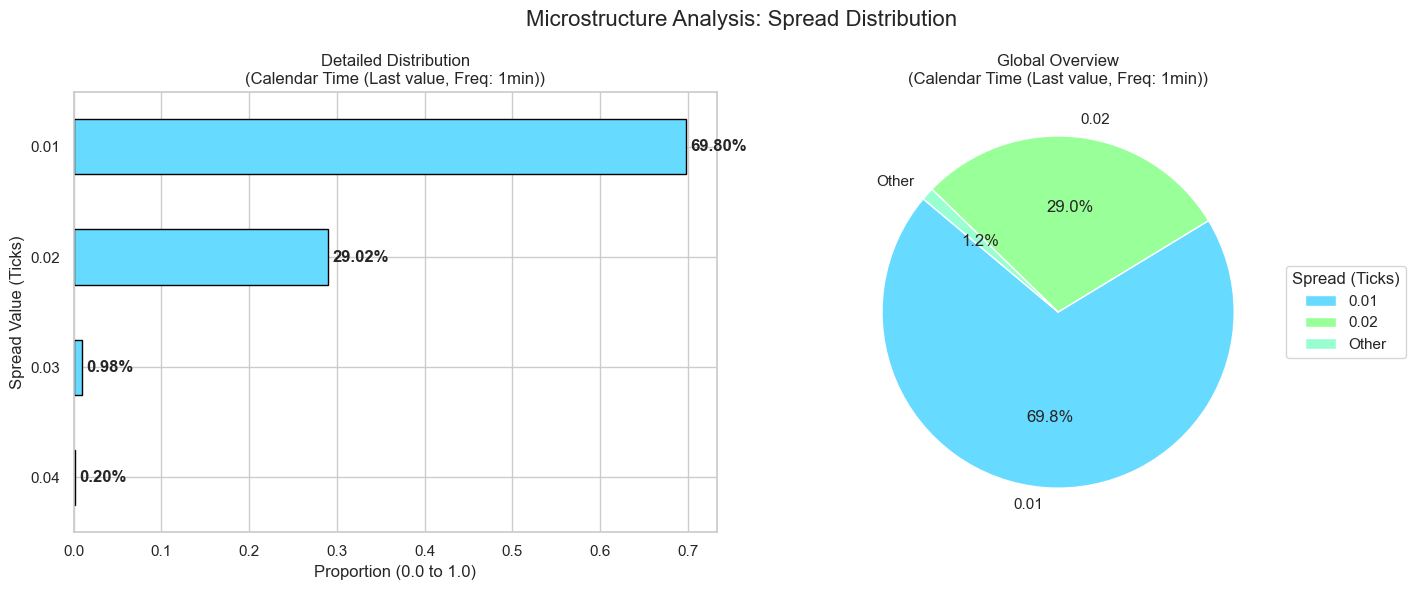

In [30]:
plot_spread_dist(update, TICKSIZE, calendar_time=True, freq='1min')

**Comment :** The distribution are quite similar. We are going to verify this !

### 2.3.3 Stationarity of the spread

We are going to visualize spread dynamics with mean, median, and quantile envelopes over time.

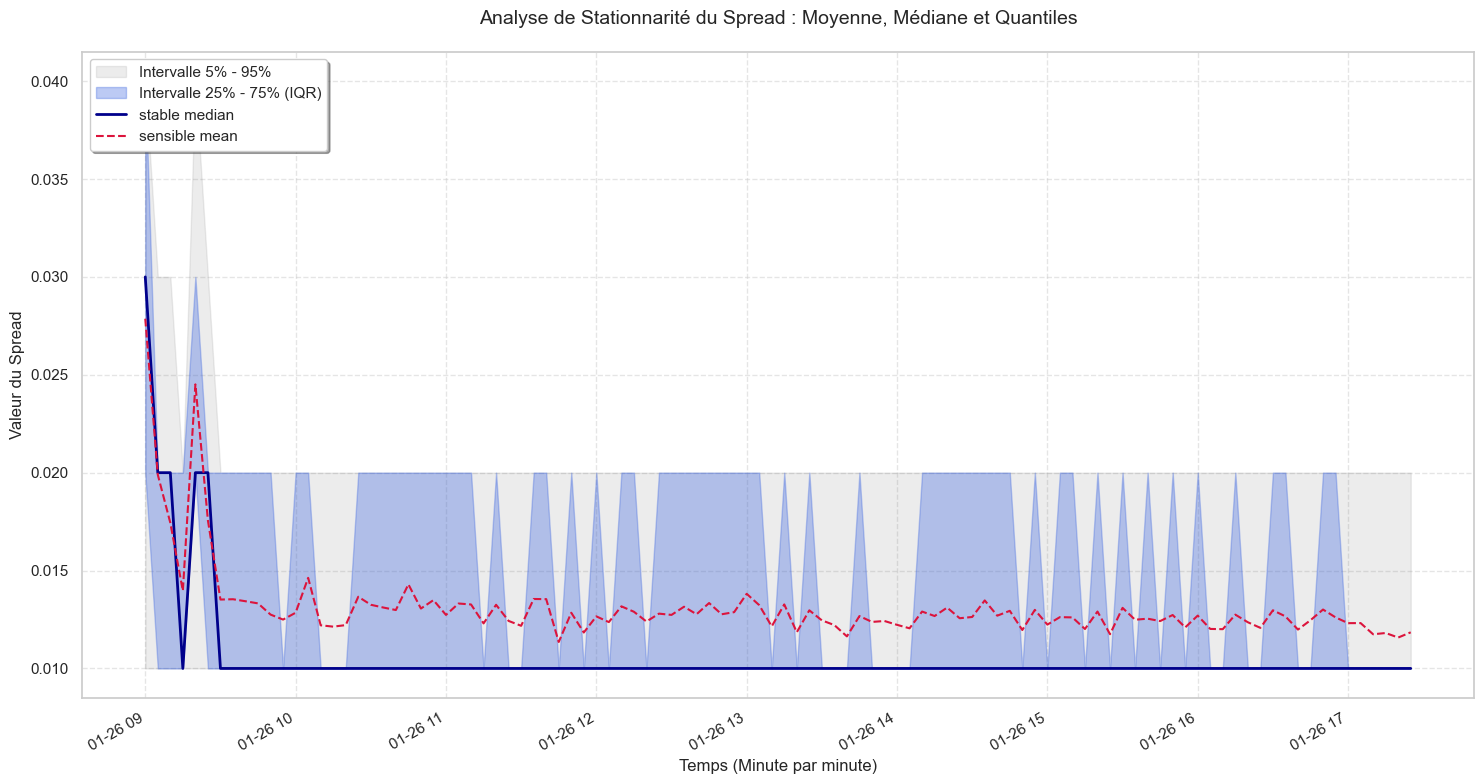

In [31]:
def display_spread(df: pd.DataFrame, freq="5min"):
    """
    Plot the evolution of the bid–ask spread using resampled statistics.

    Displays the mean, median, and quantile bands (5–95% and 25–75%) over time
    to visualize spread stability and variability.
    """
    stats = (
        df.set_index("ts")["spread"]
        .resample(freq)
        .agg(
            mean='mean',
            median='median',
            q05=lambda x: x.quantile(0.05),
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            q95=lambda x: x.quantile(0.95)
        )
    )

    plt.figure(figsize=(15, 8))

    # Zone 5% - 95% 
    plt.fill_between(stats.index, stats['q05'], stats['q95'], 
                    color='gray', alpha=0.15, label='Intervalle 5% - 95%')

    # Zone 25% - 75% 
    plt.fill_between(stats.index, stats['q25'], stats['q75'], 
                    color='royalblue', alpha=0.35, label='Intervalle 25% - 75% (IQR)')

    # Tracer la Médiane 
    plt.plot(stats.index, stats['median'], color='darkblue', 
            linewidth=2, label='stable median')

    # Tracer la Moyenne 
    plt.plot(stats.index, stats['mean'], color='crimson', 
            linestyle='--', linewidth=1.5, label='sensible mean')

    plt.title("Analyse de Stationnarité du Spread : Moyenne, Médiane et Quantiles", fontsize=14, pad=20)
    plt.xlabel("Temps (Minute par minute)", fontsize=12)
    plt.ylabel("Valeur du Spread", fontsize=12)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.gcf().autofmt_xdate() 

    plt.tight_layout()
    plt.show()

display_spread(update, freq = "5min")

**pread Stationarity Analysis**

#### 1. Visual Evidence

From the time evolution of the spread distribution (mean, median, quantiles), three regimes emerge:

- **Opening phase (≈ 09:00–09:45):** Strong instability with an initial spike followed by rapid decay. The spread is clearly **non-stationary** during early price discovery.
- **Stable regime (after ≈ 10:00):** The median stabilizes around a lower bound (~0.01), and the mean fluctuates horizontally with no visible trend.
- **Dispersion stability:** The interquantile ranges (IQR and 5–95%) remain roughly constant, suggesting stable variability despite occasional liquidity shocks.

#### 2. Informal Diagnosis

Although the opening is turbulent, the spread appears **weakly stationary** for most of the session:
- **Stable mean:** $$\mathbb{E}[s_t]$$ shows no visible drift after the opening phase.
- **Stable variance:** Dispersion remains approximately constant over time, aside from isolated spikes.

We now test this hypothesis formally.

---

### Formal Test: Augmented Dickey–Fuller (ADF)

We assess spread stationarity using the Augmented Dickey–Fuller test:
$
\Delta s_t = \alpha + \beta t + \gamma s_{t-1} + \sum_{i=1}^{p} \phi_i \Delta s_{t-i} + \varepsilon_t,
$
where $s_t$ is the spread and $p$ the number of lags.

**Hypotheses**
- $H_0: \gamma = 0$ → unit root (non-stationary spread)  
- $H_1: \gamma < 0$ → stationary spread

**Reported outputs**
- ADF statistic  
- p-value  
- Number of lags used $p$
- Effective number of observations  

**Interpretation**  
If the p-value is small (e.g. $< 0.05$), we reject $H_0$ and conclude that the spread is stationary.


In [32]:
ADF_test = adfuller(update["spread"].dropna())

print("ADF Statistic:", ADF_test[0])
print("p-value:", ADF_test[1])
print("Lags used:", ADF_test[2])
print("Observations:", ADF_test[3])

ADF Statistic: -24.575198613631333
p-value: 0.0
Lags used: 83
Observations: 226044


**Comment :** We could, indeed, assume that the spread is stationary !

## 2.4 Imbalance and mid-price moves

Intuitively, if the bid size is much larger than the ask size, buying pressure dominates and the ask is more likely to be consumed. Conversely, if the ask size is much larger, selling pressure dominates and the bid is more likely to be consumed.

Thus, order book imbalance may contain information about short-term price movements. We study whether imbalance predicts the direction of the mid-price by estimating:
$$
\mathbb{P}(\Delta m(t) > 0 \mid I(t)).
$$



We estimate how order book imbalance predicts short-term price direction.

- Imbalance values are binned over $$[-1,1]$$.
- For each bin, we compute the next price change:
$$
\Delta x_t = x_{t+1} - x_t.
$$
- We then estimate empirical conditional probabilities:
$$
\mathbb{P}(\Delta x_t > 0 \mid I_t), \quad
\mathbb{P}(\Delta x_t < 0 \mid I_t).
$$

This provides a non-parametric estimate of how imbalance relates to the probability of upward or downward price moves.


In [33]:
def plot_imbalance_x(df: pd.DataFrame, x="mid", bins=100):
    """
    Plot conditional probabilities of upward and downward price moves
    given the order book imbalance.

    The imbalance is discretized into bins and the probabilities
    P(Δx > 0|Imbalance(t)) and P(Δx < 0|Imbalance(t)) are estimated for each bin.
    """
    df = df.copy()
    
    # Define bins and categorize imbalance
    bin_edges = np.linspace(-1, 1, bins + 1)
    df['imbalance_bins'] = pd.cut(df['imbalance'], bins=bin_edges)

    # Compute delta
    df["delta"] = df[x].shift(-1) - df[x]

    # Grouping and calculating probabilities
    grouped = df.groupby('imbalance_bins', observed=False)
    pos_counts = grouped['delta'].apply(lambda val: (val > 0).sum())
    neg_counts = grouped['delta'].apply(lambda val: (val < 0).sum())
    total_counts = pos_counts + neg_counts

    # Probabilities
    p_plus = (pos_counts / total_counts).fillna(0)
    p_neg = (neg_counts / total_counts).fillna(0)

    bin_midpoints = np.array([interval.mid for interval in p_plus.index])
    
    # Plotting
    fig, ax = plt.subplots(figsize=(13, 6))
    width = (bin_edges[1] - bin_edges[0]) * 0.8 
    
    ax.bar(bin_midpoints, p_plus.values, width=width, 
           label=f'P(Δ{x} > 0) [Upward Move]', color='royalblue', alpha=0.8)
    ax.bar(bin_midpoints, p_neg.values, width=width, 
           label=f'P(Δ{x} < 0) [Downward Move]', color='indianred', alpha=0.4, bottom=0)
    
    neutral_line = ax.axvline(0, color="black", linestyle="--", lw=1, label="Neutral Imbalance")
    threshold_line = ax.axhline(0.5, color="gray", linestyle=":", lw=1, label="50% Threshold")

    
    ax.set_title(f'Conditional Probability of Price Movement Given Order Book Imbalance ({x})', fontsize=14)
    ax.set_xlabel('Order Book Imbalance (Unitless ratio [-1, 1])', fontsize=12)
    ax.set_ylabel('Probability', fontsize=12)
    
    
    ax.grid(axis="y", alpha=0.3)

    # Figure-level legend below the plot
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=15,        
    frameon=True,
    columnspacing=1.0,  
    handlelength=1.2,   
    handletextpad=0.4,  
    borderpad=0.3       
    )

    plt.subplots_adjust(bottom=0.22)
    plt.show()

**Imbalance mid_price move**

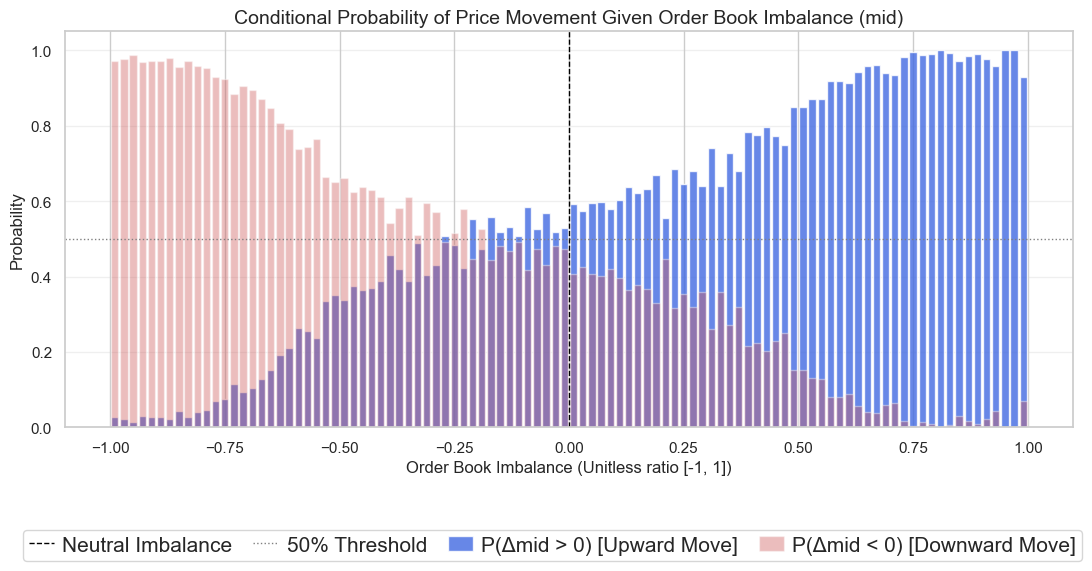

In [34]:
plot_imbalance_x(update,x="mid",bins=100)

**Analysis of Order Book Dynamics**

#### **I. Imbalance and Mid-Price Correlation**
The relationship between the imbalance $I$ and the change in mid-price $\Delta M$ follows the **Price Pressure Hypothesis**:

* **Ask-Side Heavy ($I \to -1$):** We observe $\Delta M < 0$. The bid side is "thin," and sell pressure leads to downward price shifts.
* **Bid-Side Heavy ($I \to 1$):** We observe $\Delta M > 0$. The ask side is depleted by aggressive buying, pushing the price upward.
* **Balanced State ($I \approx 0$):** The distribution of $\Delta M$ is roughly symmetric, consistent with a non-arbitrage environment where:
$$E[\Delta M | I \approx 0] \approx 0$$

**Imbalance spread move**

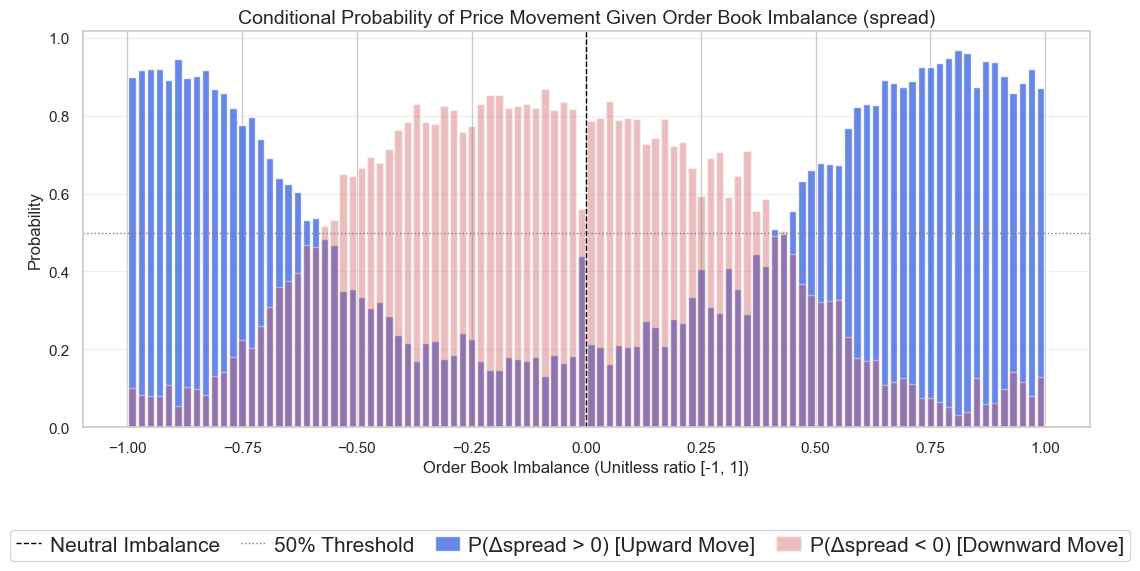

In [35]:
plot_imbalance_x(update,x="spread",bins=100)

**Analysis of Order Book Dynamics**

#### **II. Imbalance and Spread Dynamics**
The bid-ask spread $S$ reflects liquidity resilience and exhaustion:

* **High Imbalance ($|I| \to 1$):** The spread tends to **widen**. As the "thin" side of the book is consumed, the best quote moves to the next available level $L_{n+1}$, increasing the distance between $P_{bid}$ and $P_{ask}$.
* **Equilibrium ($I \approx 0$):** The spread is at its **minimum**. High liquidity and low inventory risk for market makers lead to tighter quotes:
$$S_{min} \propto \frac{1}{\text{Liquidity Density}}$$

# Question 3

## 3.1 Coherence of datasets

We aggregate trades by timestamp and price, summing quantities.
Updates are cleaned by removing consecutive duplicate trade-type rows and keeping only trade updates, then grouped by timestamp with best bid/ask prices and max sizes.
We align trades to the nearest update using an as-of merge on timestamp with a tolerance based on the largest trade gap.
Trade direction is inferred by matching trade price to bid/ask within half a tick and validating size against available depth.
Finally, we compute order book imbalance and merge the enriched features back into the original trade dataset.

In [36]:
def function(trade : pd.DataFrame, update : pd.DataFrame, ticksize):

    trade1 = trade.copy()

    update.dropna(inplace=True)

    grouped_trade = trade.groupby(
        ["ts", "price"],
        as_index=False
    ).agg({
        "qty": "sum"
    })

    mask = (
    (update['type'] == 'T') &
    (update['type'].shift() == 'T') &
    (update['ap'] == update['ap'].shift()) &
    (update['bp'] == update['bp'].shift())
    )

    update_clean = update[~mask].copy()

    update_clean_only_trades = update_clean[update_clean["type"] == "T"].dropna()

    grouped_update = update_clean_only_trades.groupby(["ts", "ap", "bp"], as_index=False).agg(
    {
        "aq" : "max",
        "bq" : "max"
    }
    )

    tolerance = grouped_trade["ts"].sort_values().diff().max()

    grouped_update['update_id'] = grouped_update.index

    merged = pd.merge_asof(
        grouped_trade, 
        grouped_update, 
        on='ts', 
        tolerance=tolerance,
    )

    merged["mp"] = (merged["ap"] + merged["bp"])/2
    ask_match = merged["price"] >=  merged["mp"]  
    bid_match = merged["price"] < merged["mp"]



    merged["sign"] = np.select(
        [ask_match, bid_match],
        [1, -1],
        default=np.nan
    )

    merged["imbalance"] = (merged["bq"]-merged["aq"])/(merged["bq"]+merged["aq"])

    new_merged = merged.loc[merged.groupby("ts")["price"].idxmax()].reset_index(drop=True)

    trade1 = pd.merge(trade1,new_merged,on = "ts", how = "left")

    return trade1


In [37]:
merged_trade_update = function(trade,update, TICKSIZE)

## 3.2 Imbalance vs Trade sign

Let's display the relationship between Trade sign and Imbalance

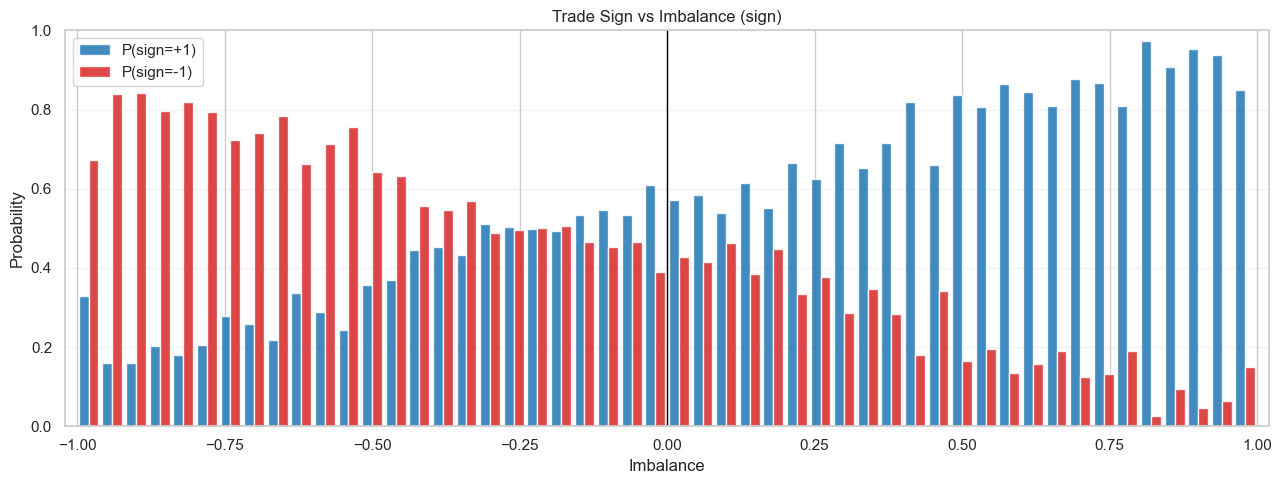

In [38]:
def plot_imbalance_sign(df, sign_col="sign", bins=50):
    """
    Plot conditional probabilities of trade signs (+1 / -1) given order book imbalance.

    The imbalance is discretized into bins and the probabilities
    P(sign = +1) and P(sign = -1) are estimated for each bin.
    """
    d = df.copy()

    edges = np.linspace(-1, 1, bins + 1)
    d["imb_bin"] = pd.cut(d["imbalance"], bins=edges, include_lowest=True)

    g = d.groupby("imb_bin", observed=False)[sign_col]
    n_plus = g.apply(lambda s: (s == 1).sum())
    n_minus = g.apply(lambda s: (s == -1).sum())
    n_total = n_plus + n_minus

    
    p_plus = (n_plus / n_total).fillna(0)
    p_minus = (n_minus / n_total).fillna(0)

    mids = np.array([iv.mid for iv in p_plus.index])
    w = (edges[1] - edges[0]) * 0.42

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(mids - w/2, p_plus.values, width=w, label="P(sign=+1)", color="tab:blue", alpha=0.85)
    ax.bar(mids + w/2, p_minus.values, width=w, label="P(sign=-1)", color="tab:red", alpha=0.85)

    ax.set_xlim(-1.02, 1.02)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Imbalance")
    ax.set_ylabel("Probability")
    ax.set_title(f"Trade Sign vs Imbalance ({sign_col})")
    ax.axvline(0, color="black", lw=1)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_imbalance_sign(merged_trade_update, sign_col = "sign")

**Comment :** Order book imbalance reflects which side has more resting liquidity.
When bid size dominates (positive imbalance), stronger buy-side pressure makes it more likely that buyers consume the ask, leading to buy trades.
Conversely, when ask size dominates (negative imbalance), sell pressure increases and trades are more likely to hit the bid.
Near zero imbalance, neither side clearly dominates, so trade direction becomes less predictable.

**Note :** The Imbalance-Spread relationship was treated before.

## 3.3 Autocorrelation function of trade signs



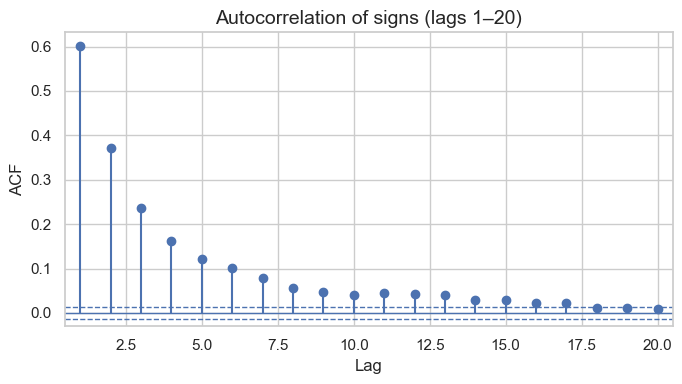

In [39]:
from statsmodels.tsa.stattools import acf


def plot_autocorr(df, lags=8):
    """
    Plot the autocorrelation function of the trade sign series,
    excluding lag 0.
    """
    x = df["sign"].dropna().to_numpy()

    acf_vals = acf(x, nlags=lags, fft=True)

    # Remove lag 0
    lags_arr = np.arange(1, lags + 1)
    acf_vals = acf_vals[1:]

    # Approximate confidence bands
    conf = 1.96 / np.sqrt(len(x))

    fig, ax = plt.subplots(figsize=(7, 4))

    markerline, stemlines, baseline = ax.stem(
        lags_arr, acf_vals, basefmt=" "
    )

    plt.setp(markerline, markersize=6)
    plt.setp(stemlines, linewidth=1.5)

    ax.axhline(0, linewidth=1)
    ax.axhline(conf, linestyle="--", linewidth=1)
    ax.axhline(-conf, linestyle="--", linewidth=1)

    ax.set_title(f"Autocorrelation of signs (lags 1–{lags})", fontsize=14)
    ax.set_xlabel("Lag", fontsize=12)
    ax.set_ylabel("ACF", fontsize=12)
    ax.set_xlim(0.5, lags + 0.5)

    plt.tight_layout()
    plt.show()

plot_autocorr(merged_trade_update,20)

**Comment :** The ACF plot shows a significant positive autocorrelation that decays slowly as the lags increase. At lag 1, the correlation is approximately 0.6, indicating a very high probability that the sign of a trade will be the same as the previous one.